# metro c360
deep dive into each activity

In [1]:
import os
import numpy as np 
from astropy.table import Table

In [2]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
data_binary = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/data_binary_act.hdf5')
metro = data_binary[data_binary['arch'] == 'metro']
YX_metro = np.array([np.array(metro[col]) for col in metro.colnames[:-2]]).T

In [4]:
def dY_jackknife(dY, zipcodes, func=np.median, njack=5): 
    ''' jackknife uncertainties 
    '''
    mu_dY = func(dY)
    
    mu_dY_jack, n_jack = [], 0
    for i in range(njack): 
        in_jack = ((zipcodes % njack) == i)
        if np.sum(in_jack) == 0: continue
            
        mu_dY_jack.append(func(dY[~in_jack]))
        n_jack += 1
    if n_jack < 3: return np.inf
    
    mu_dY_jack = np.array(mu_dY_jack)
    
    sig_jack = np.sqrt((n_jack - 1)/n_jack * np.sum((mu_dY_jack - mu_dY)**2))
    return sig_jack

## examine natural experiments

In [5]:
experiments = [(0, 1), (9, 8), (64, 65), (66, 67)]

In [6]:
all_ctes, all_zips = [], [] 

### experiment 1

In [7]:
# 0 - 1
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/metro.0_1.hdf5')

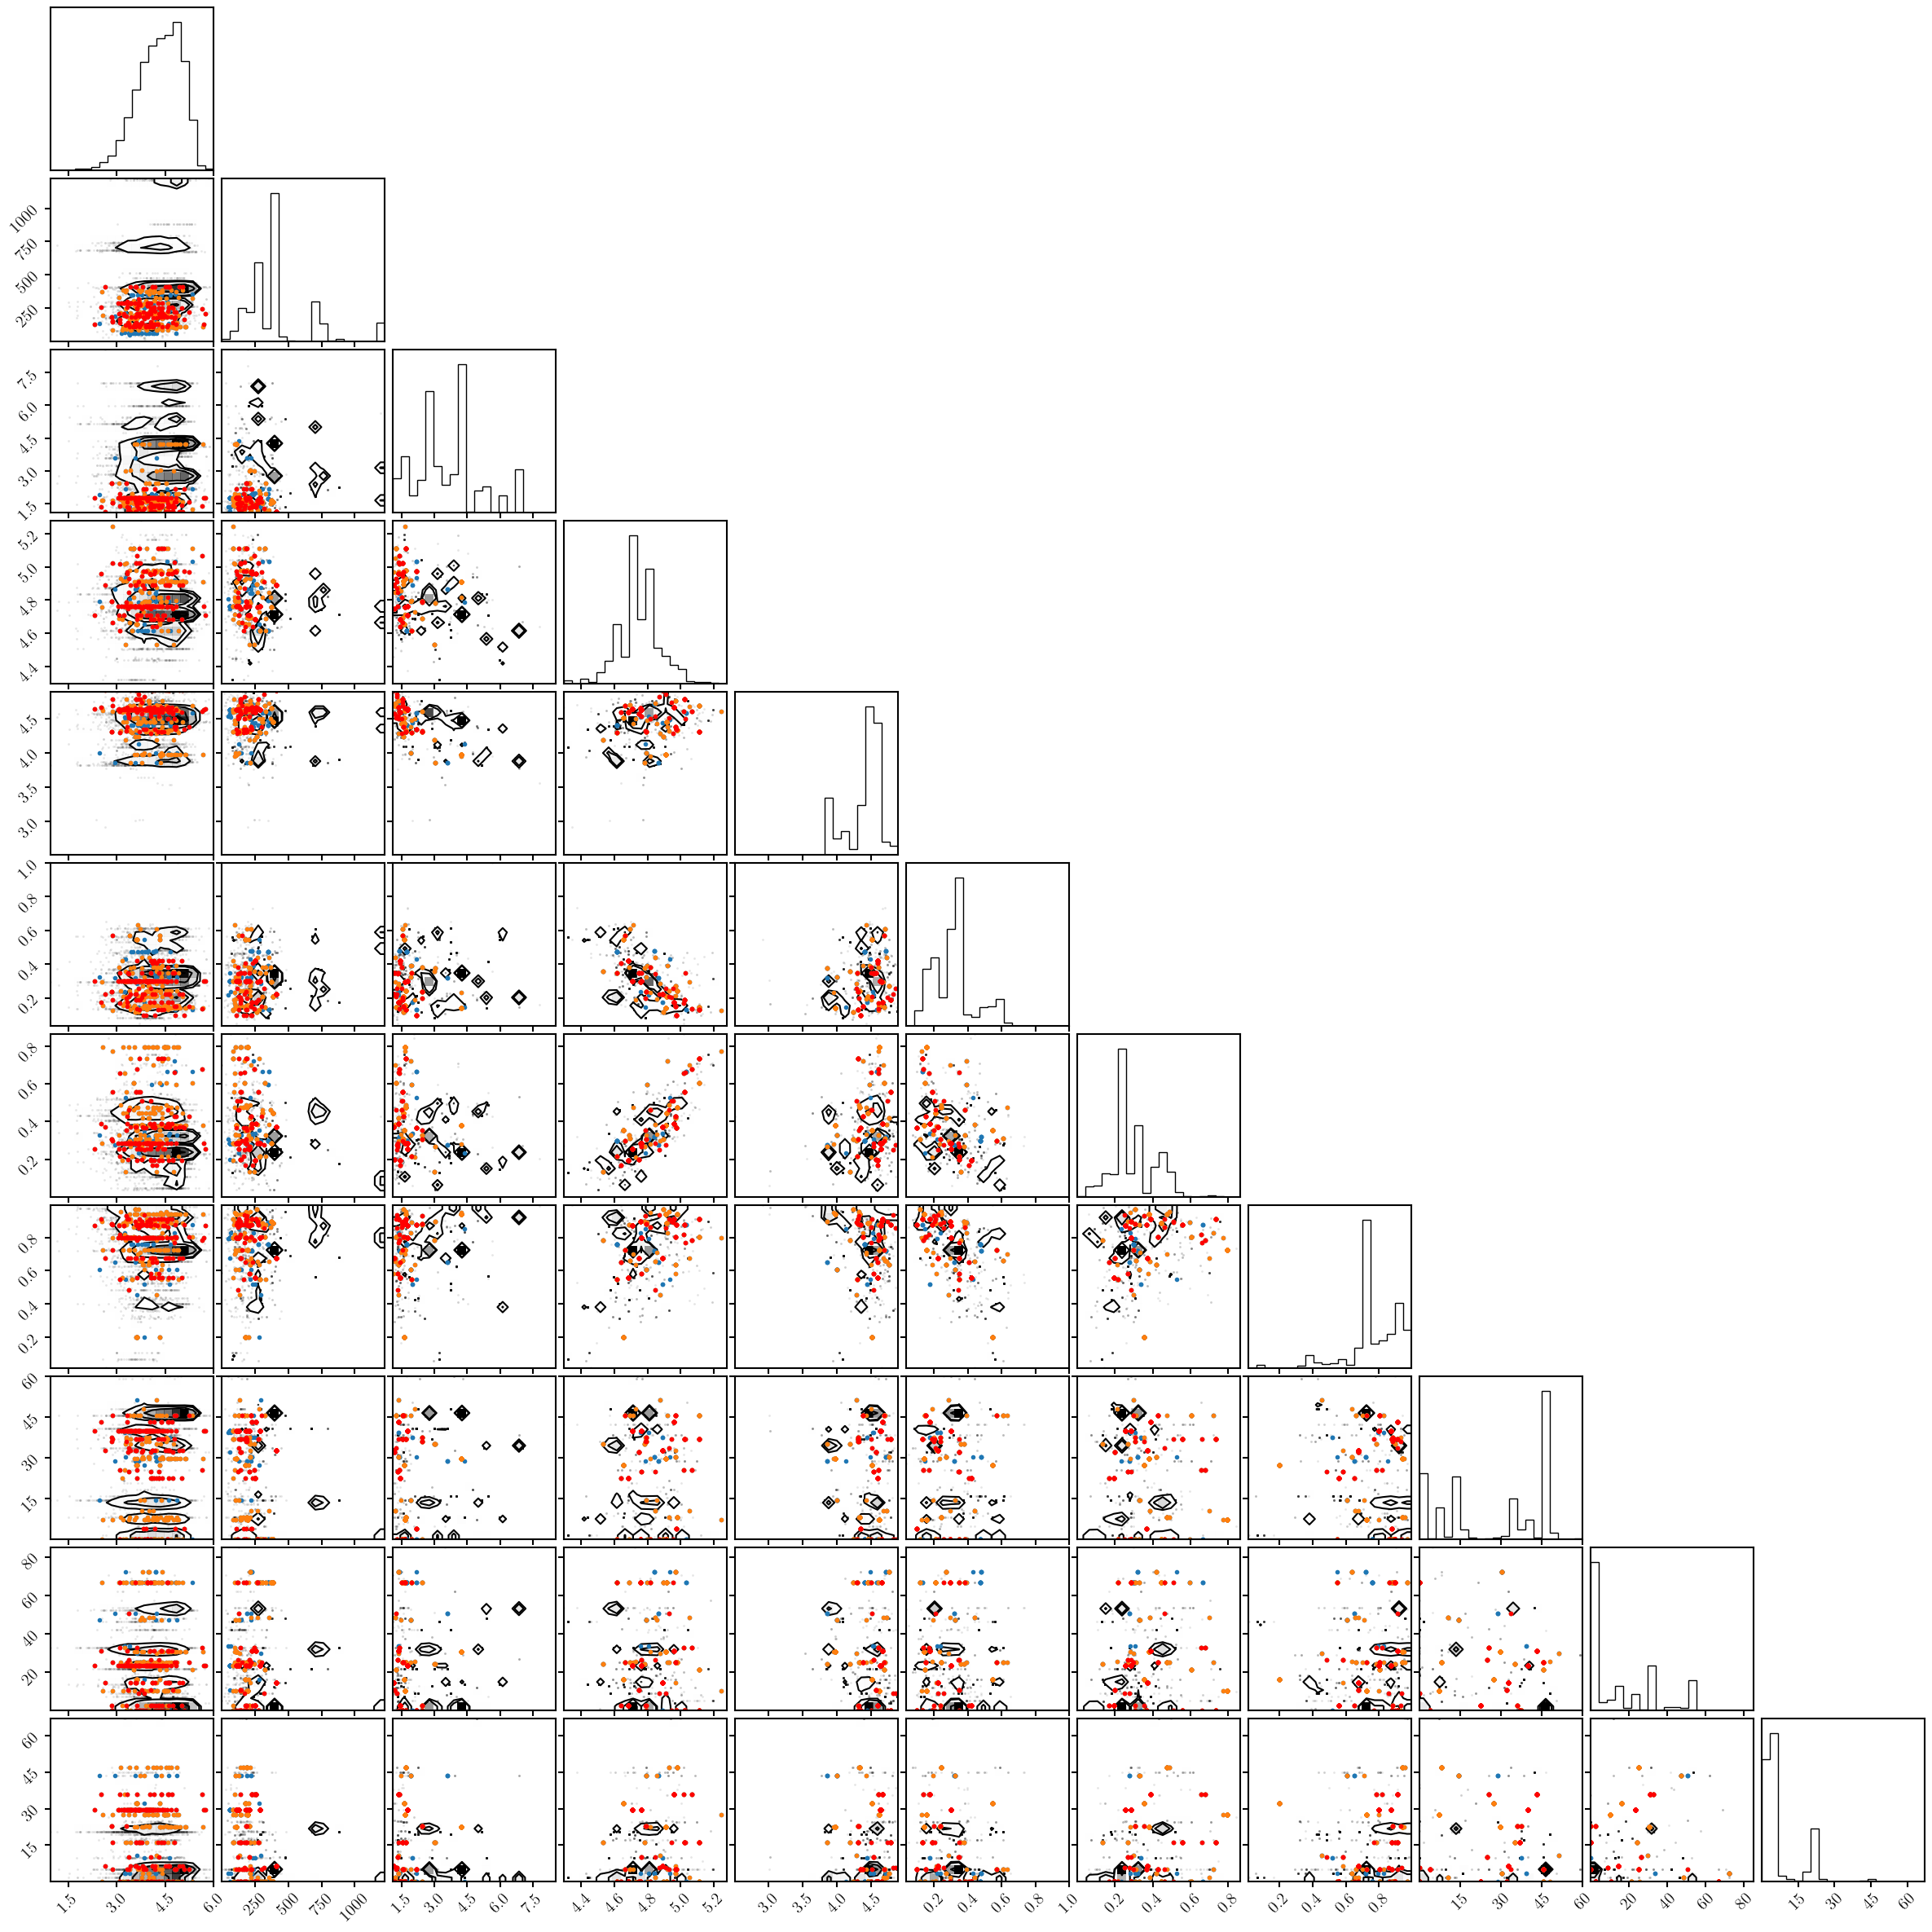

In [8]:
fig = DFM.corner(YX_metro[metro['binary_code'] == 0])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.95], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.8], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.5], color='r')

In [9]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5)))

-8105.62 \pm 1132.70
-8213.43 \pm 1321.81
-8148.00 \pm 1670.89
-8105.62 \pm 1764.94
-10633.88 \pm 2864.03


In [10]:
cut = (exp_data['p_support'] < 0.95)
all_ctes.append(exp_data['CTE'][cut])
all_zips.append(exp_data['zipcode'][cut])

### experiment 2

In [31]:
# 8 - 9
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/metro.8_9.hdf5')

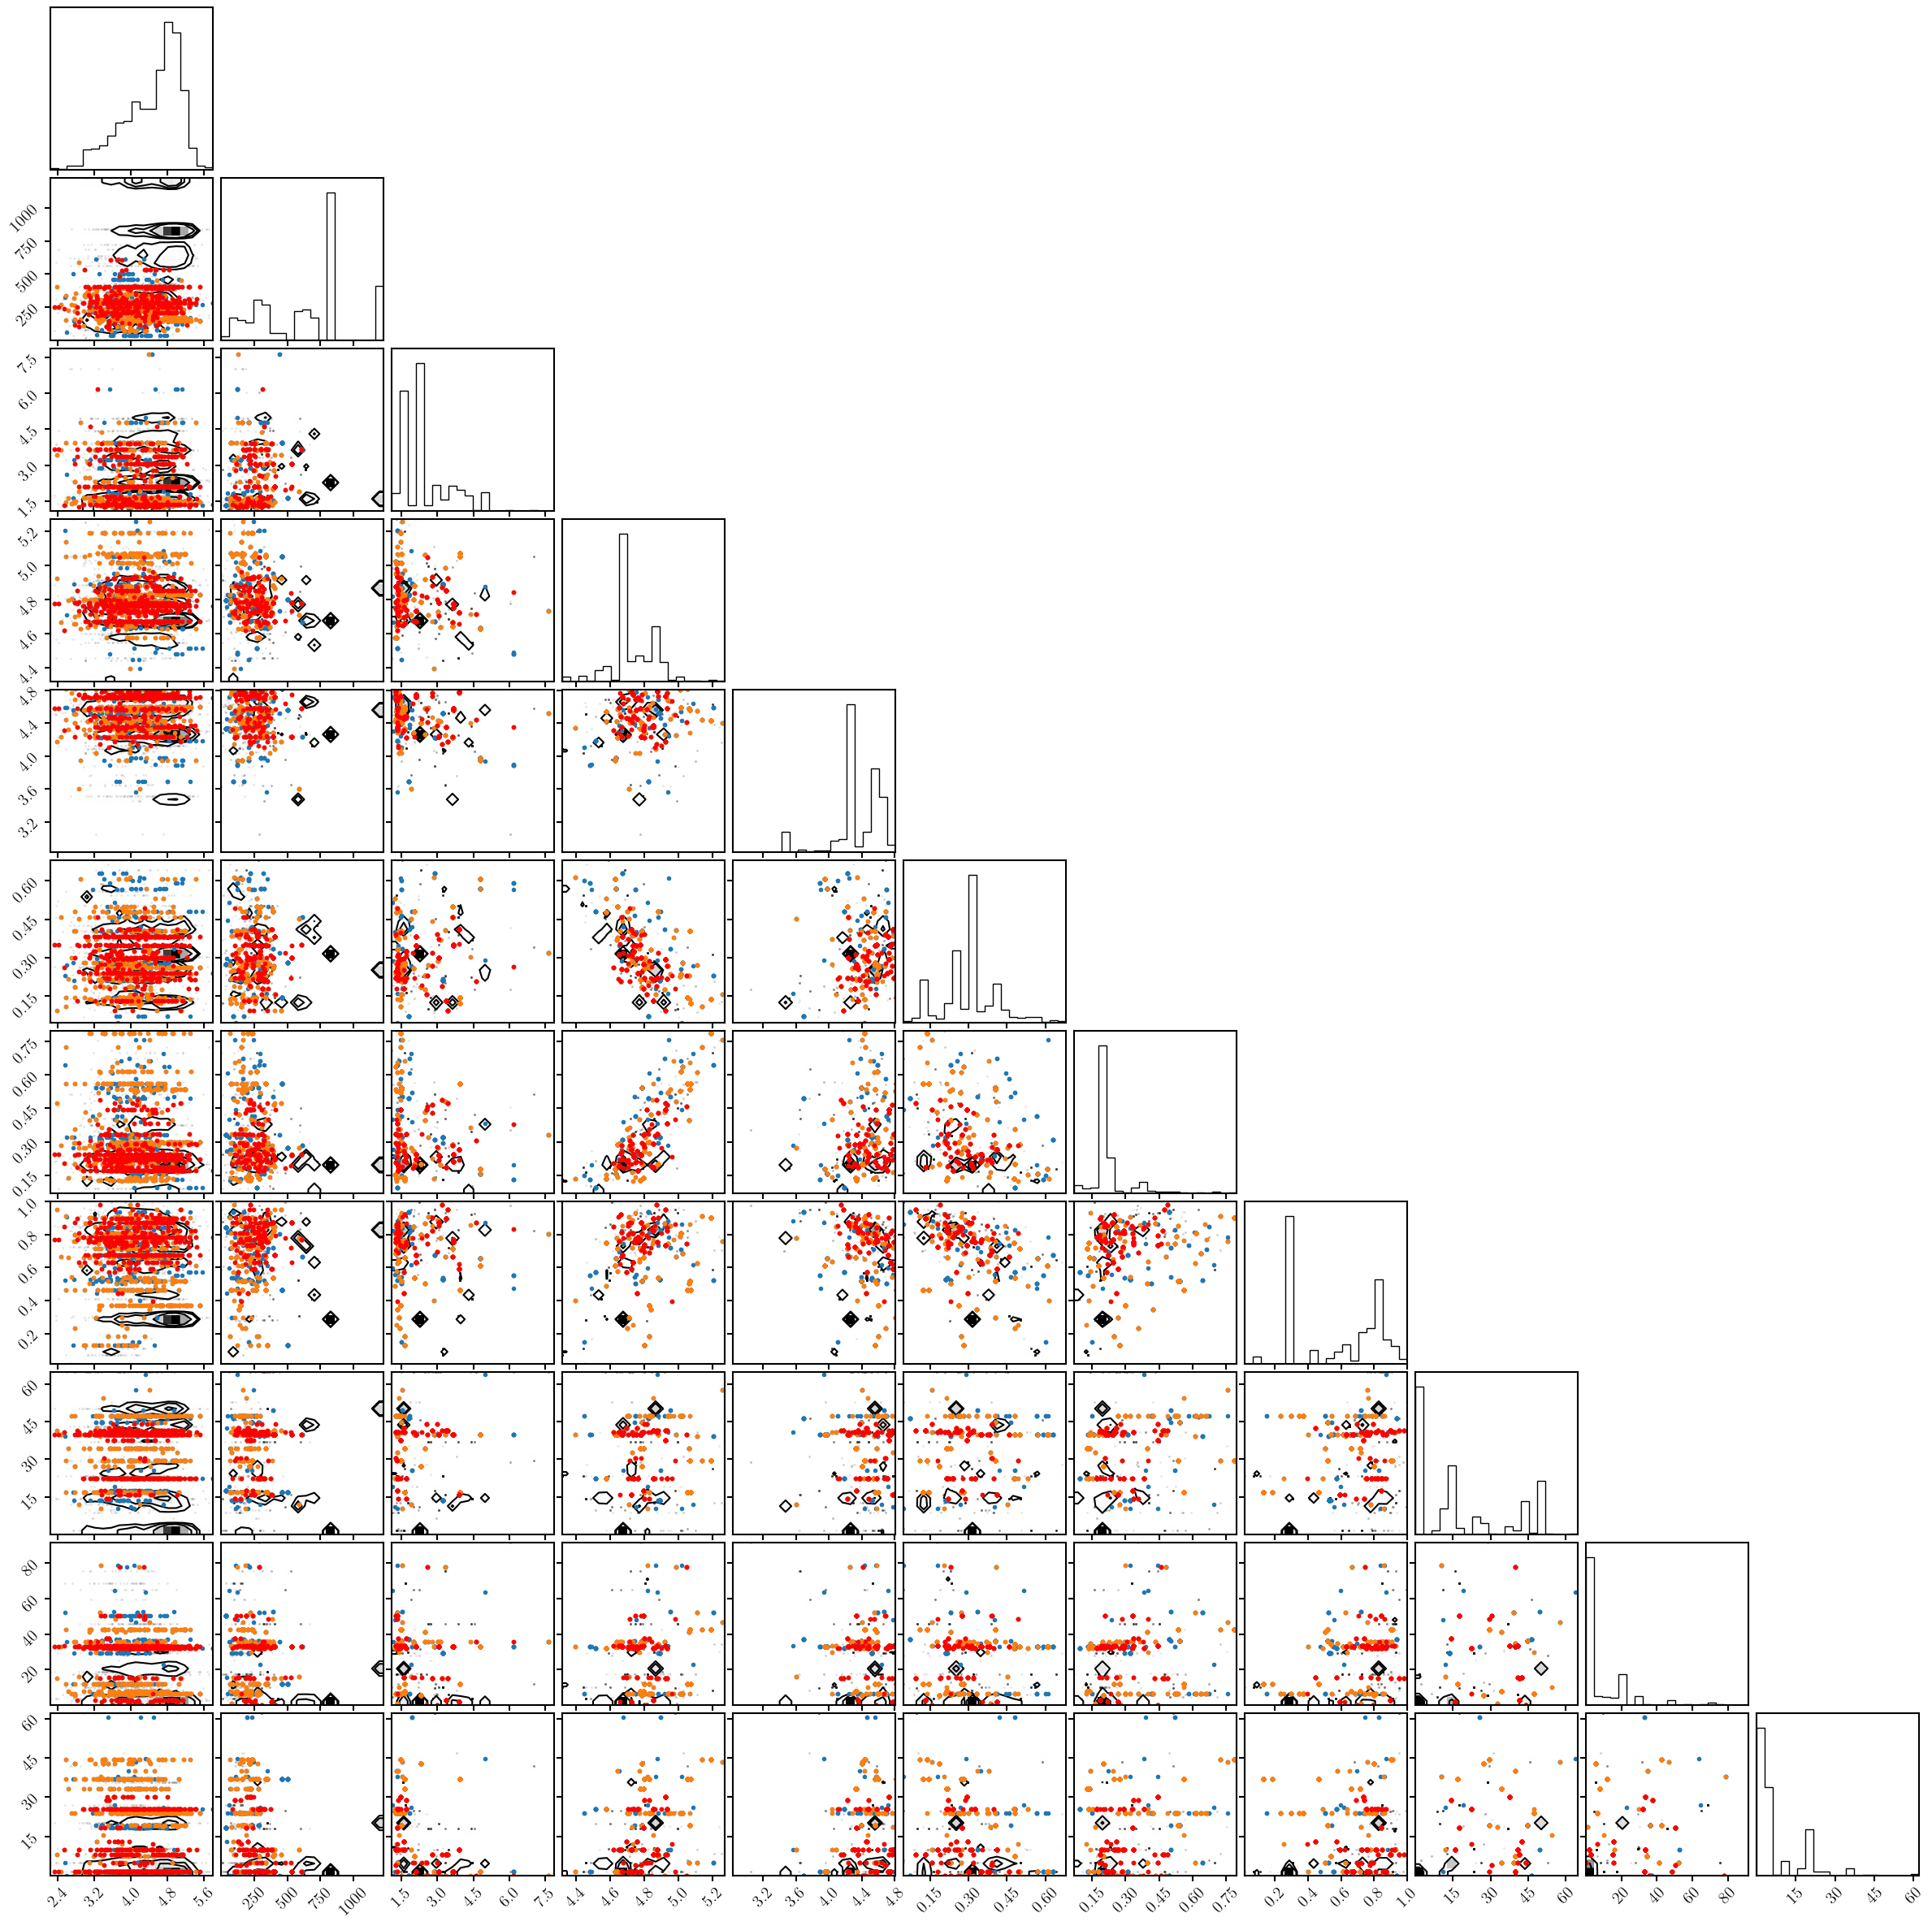

In [32]:
fig = DFM.corner(YX_metro[metro['binary_code'] == 8])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.95], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.8], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.5], color='r')

In [33]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-8809.53 \pm 2083.75 (1043)
-8587.57 \pm 2081.13 (1012)
-8579.93 \pm 1904.59 (933)
-9476.96 \pm 1349.58 (840)
-8764.57 \pm 2442.45 (444)


In [35]:
cut = (exp_data['p_support'] < 0.95)
all_ctes.append(exp_data['CTE'][cut])
all_zips.append(exp_data['zipcode'][cut])

### experiment 3

In [36]:
# 64-65
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/metro.64_65.hdf5')

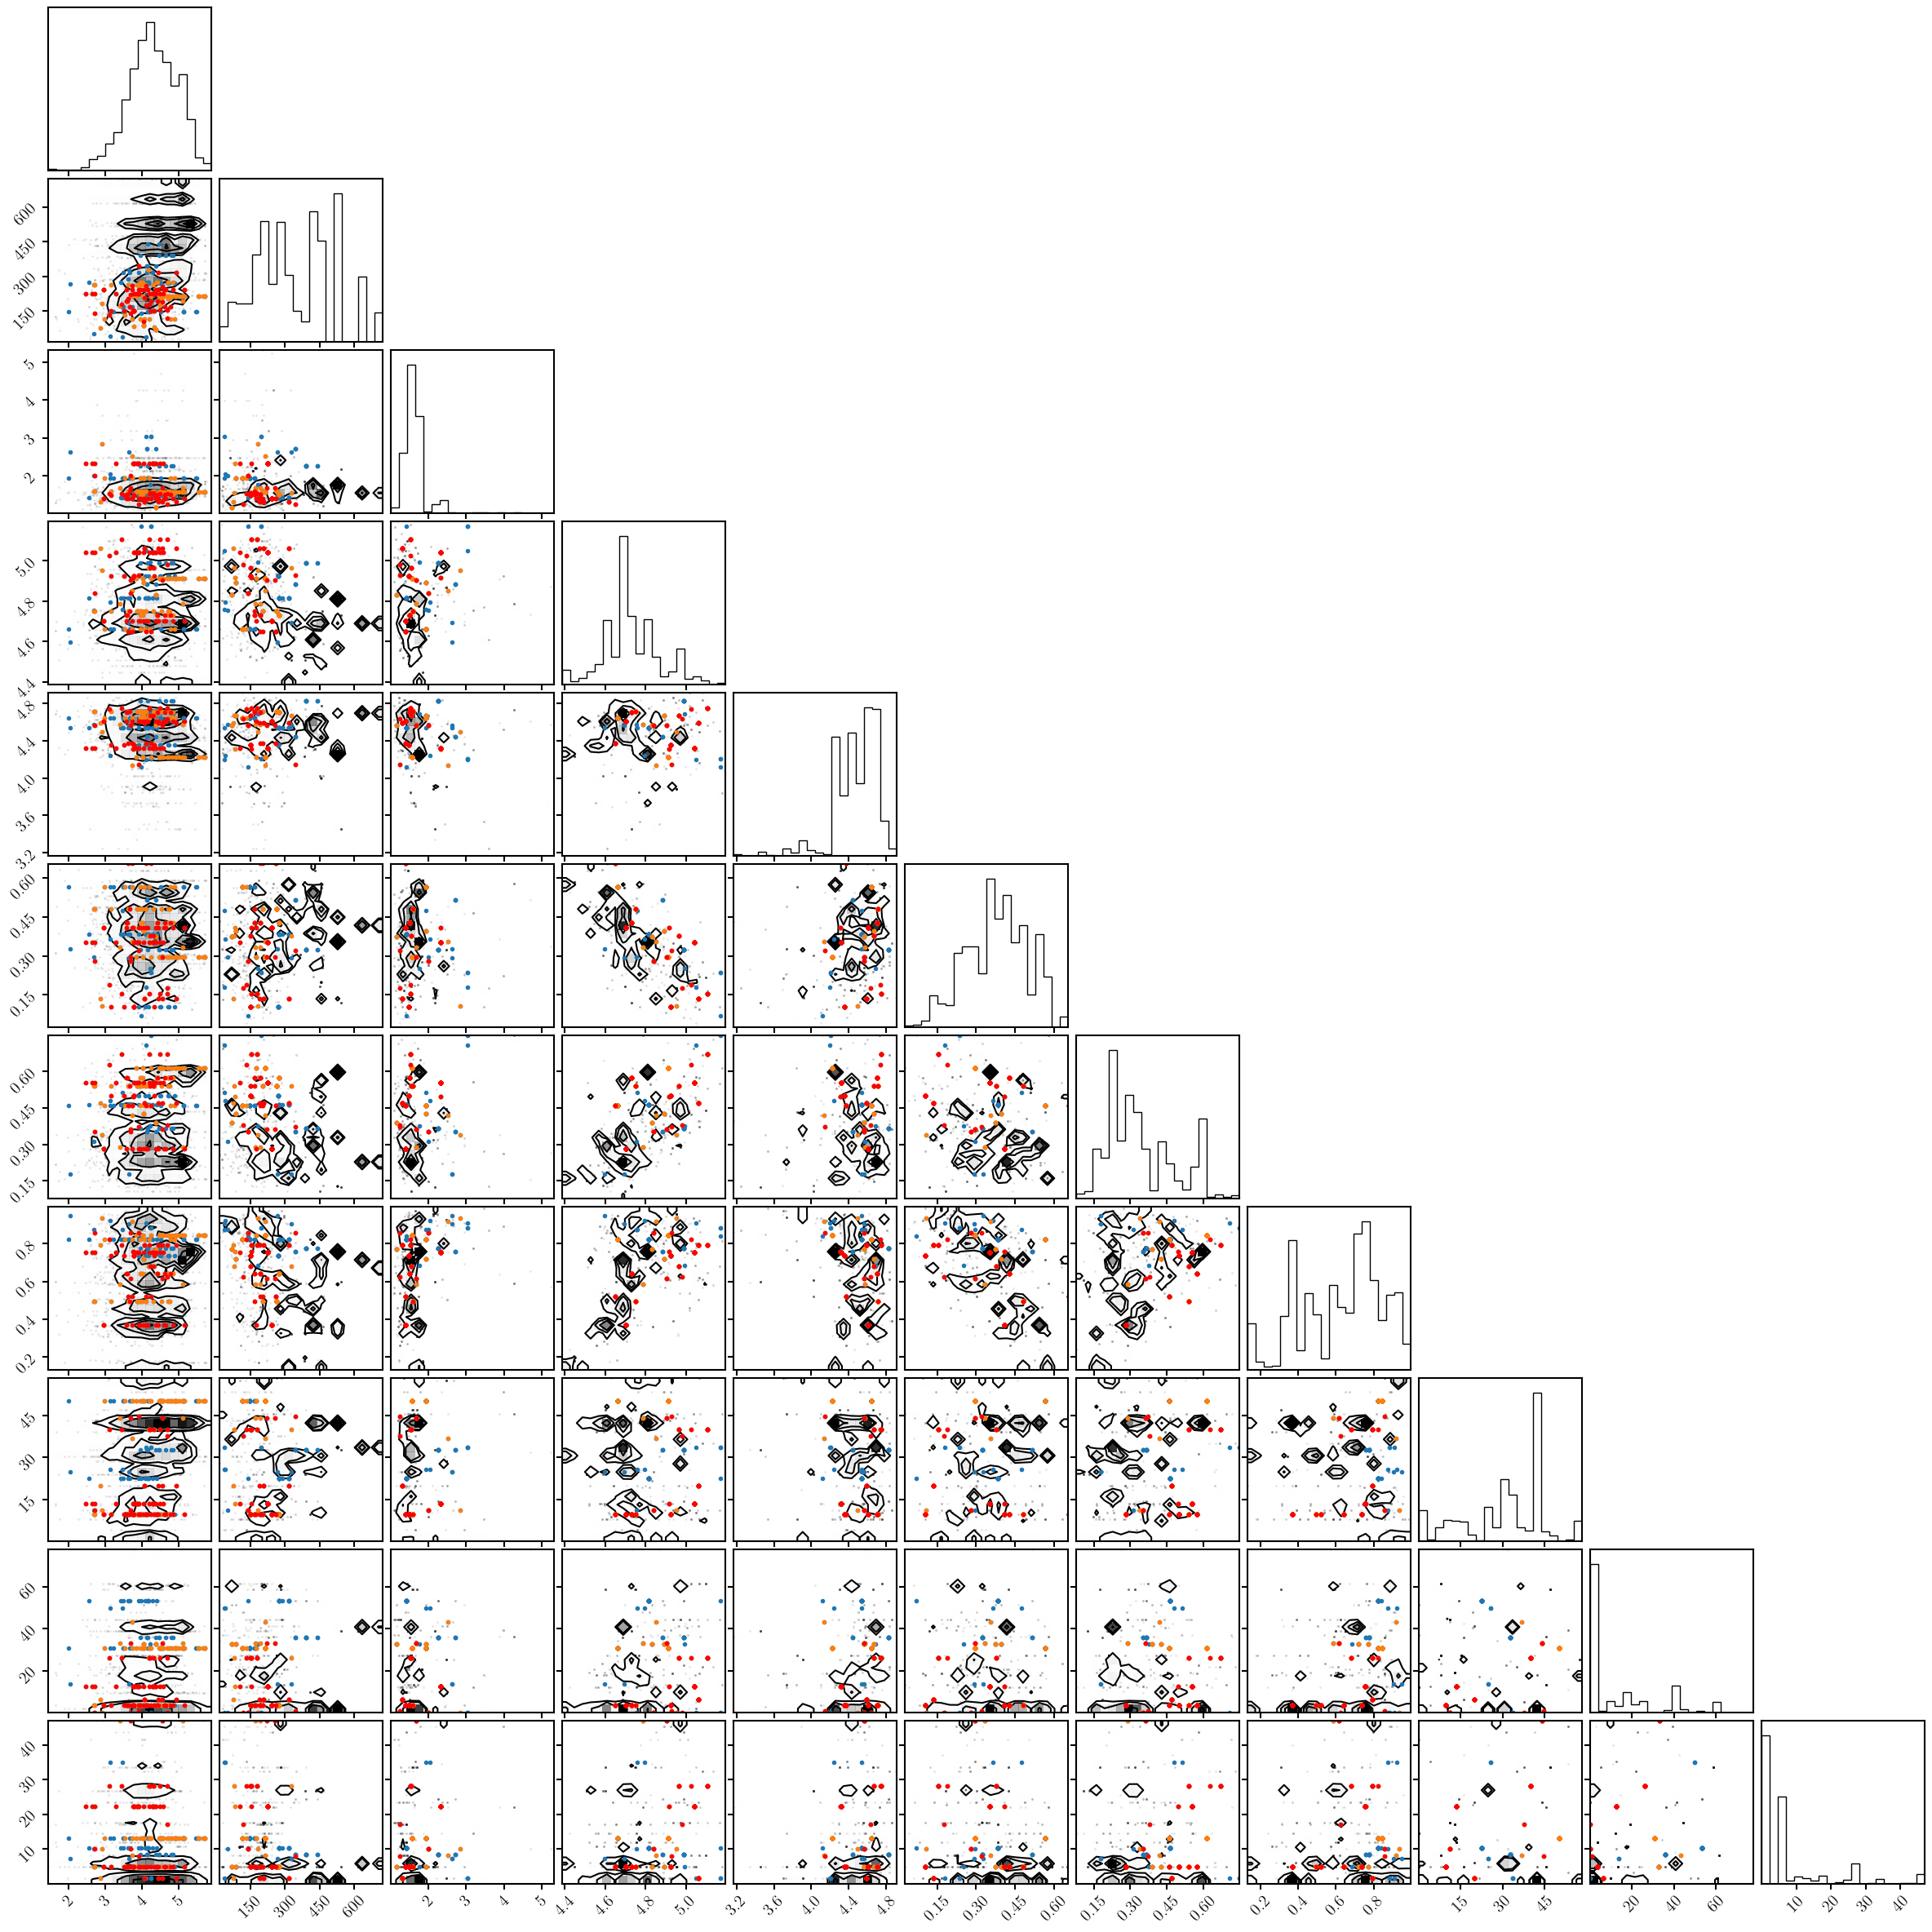

In [37]:
fig = DFM.corner(YX_metro[metro['binary_code'] == 64])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.95], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.8], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.5], color='r')

In [38]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-10534.37 \pm 2956.98 (199)
-8952.73 \pm 5061.47 (181)
-8316.71 \pm 5270.74 (174)
-8688.48 \pm 4406.17 (143)
-9522.96 \pm 7407.33 (70)


In [39]:
cut = (exp_data['p_support'] < 0.8)
all_ctes.append(exp_data['CTE'][cut])
all_zips.append(exp_data['zipcode'][cut])

### experiment 4

In [41]:
# 66-67
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/metro.66_67.hdf5')

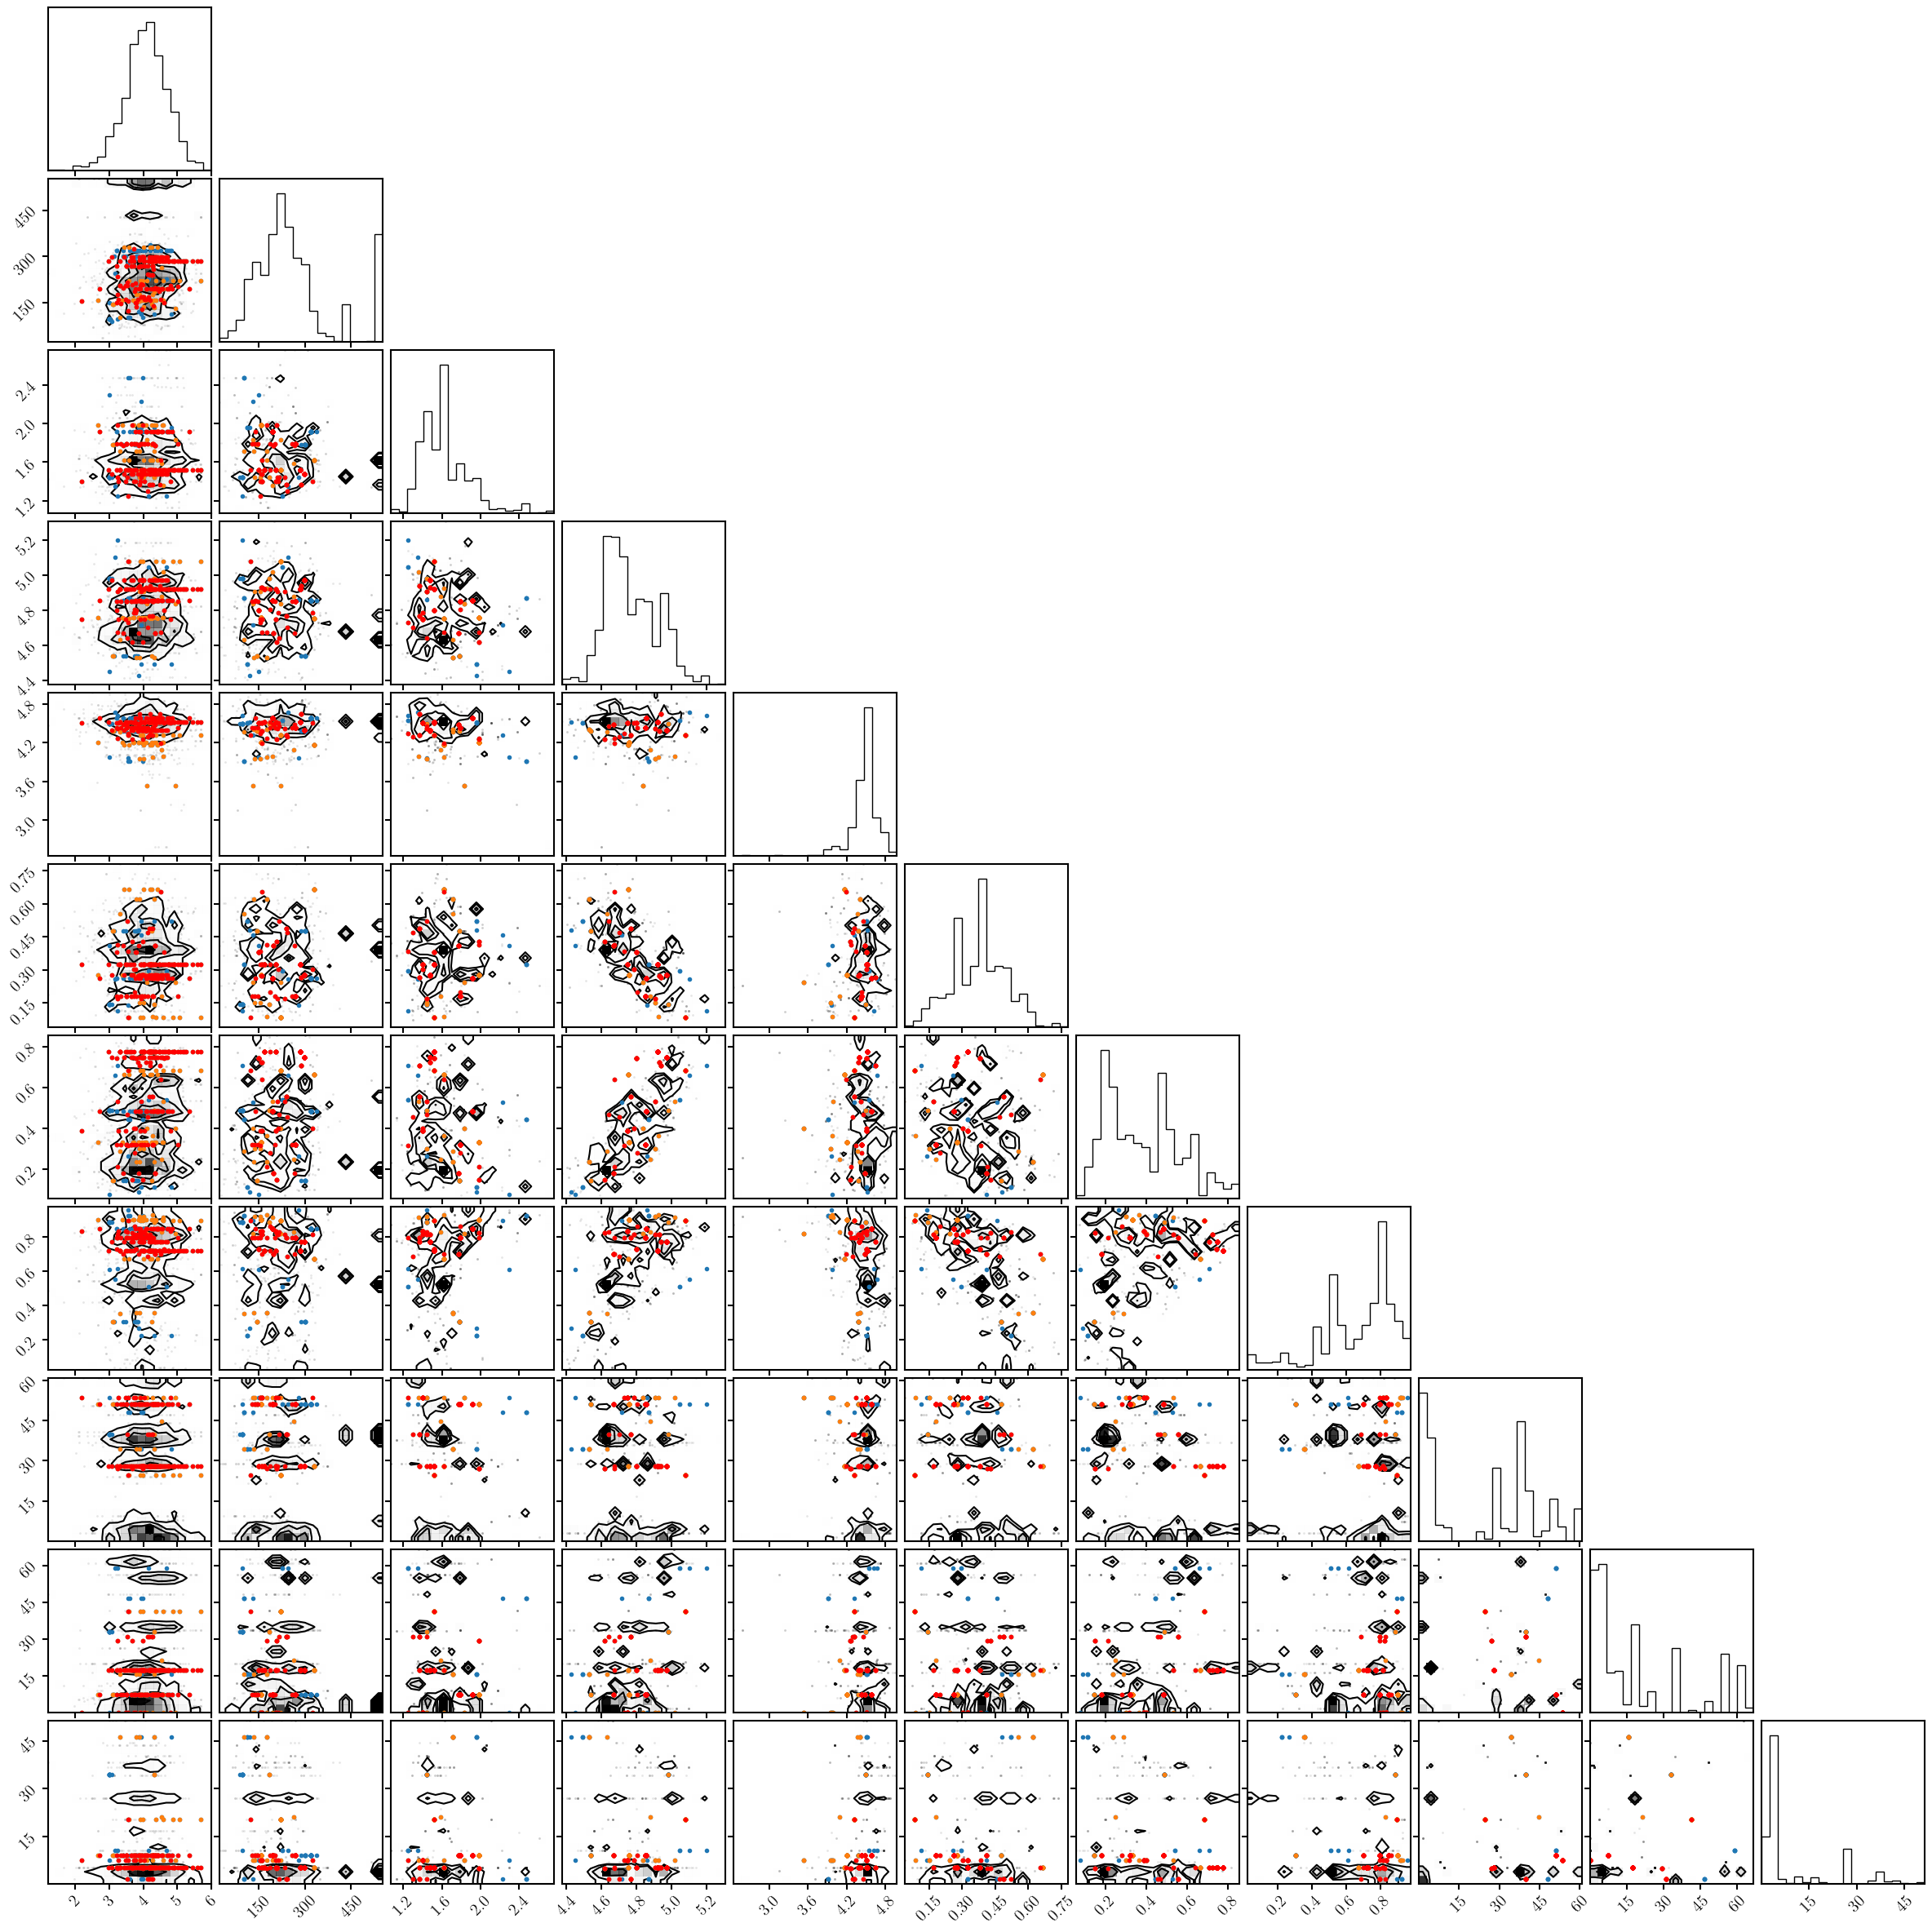

In [42]:
fig = DFM.corner(YX_metro[metro['binary_code'] == 66])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.95], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.8], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.5], color='r')

In [43]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f (%i)' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5), np.sum(cut)))

-5776.17 \pm 2442.47 (250)
-4384.55 \pm 2230.64 (237)
-4027.10 \pm 1097.83 (220)
-3772.05 \pm 2007.75 (200)
-3375.79 \pm 1648.60 (156)


In [44]:
cut = (exp_data['p_support'] < 0.8)
all_ctes.append(exp_data['CTE'][cut])
all_zips.append(exp_data['zipcode'][cut])

## combined

In [46]:
# get jackknife for single experiment
sig_jack = dY_jackknife(np.concatenate(all_ctes), np.concatenate(all_zips), func=np.median, njack=5)
print('  %.2f \pm %.2f' % (np.median(np.concatenate(all_ctes)), sig_jack))

  -7784.32 \pm 545.91
